# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Indian Sales Transactions Dataset](https://www.kaggle.com/datasets/arunkumaroraon/indian-sales-transactions-dataset-2025)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('sales_data.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,Order_ID,Date,Region,Salesperson,Category,Product,Quantity,Unit_Price,Sales,Profit
0,ORD00001,2025-07-19,West,Sneha,Electronics,Laptop,12,50000,600000,83914
1,ORD00002,2025-08-13,West,Sneha,Furniture,Table,14,8000,112000,19810
2,ORD00003,2025-08-25,North,Amit,Electronics,Laptop,14,50000,700000,137261
3,ORD00004,2025-01-30,East,Arun,Electronics,Laptop,3,50000,150000,17069
4,ORD00005,2025-03-09,West,Rahul,Electronics,Laptop,17,50000,850000,248242


## last Five row

In [4]:
df.tail()

,Order_ID,Date,Region,Salesperson,Category,Product,Quantity,Unit_Price,Sales,Profit
9995,ORD09996,2025-08-02,South,Priya,Electronics,Laptop,17,50000,850000,206066
9996,ORD09997,2025-12-05,South,Priya,Furniture,Chair,14,3000,42000,8466
9997,ORD09998,2025-01-26,North,Amit,Electronics,Laptop,9,50000,450000,129311
9998,ORD09999,2025-08-22,East,Arun,Electronics,Monitor,7,12000,84000,14979
9999,ORD10000,2025-10-31,East,Riya,Furniture,Chair,12,3000,36000,5946


## Shape of our dataset

In [5]:
df.shape

(10000, 10)

## List out all columns

In [6]:
df.columns

Index(['Order_ID', 'Date', 'Region', 'Salesperson', 'Category', 'Product',
       'Quantity', 'Unit_Price', 'Sales', 'Profit'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

Order_ID       object
Date           object
Region         object
Salesperson    object
Category       object
Product        object
Quantity        int64
Unit_Price      int64
Sales           int64
Profit          int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Order_ID     10000 non-null  object
 1   Date         10000 non-null  object
 2   Region       10000 non-null  object
 3   Salesperson  10000 non-null  object
 4   Category     10000 non-null  object
 5   Product      10000 non-null  object
 6   Quantity     10000 non-null  int64 
 7   Unit_Price   10000 non-null  int64 
 8   Sales        10000 non-null  int64 
 9   Profit       10000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 781.4+ KB


## Check Null Value

In [9]:
df.isnull().sum()

Order_ID       0
Date           0
Region         0
Salesperson    0
Category       0
Product        0
Quantity       0
Unit_Price     0
Sales          0
Profit         0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,Quantity,Unit_Price,Sales,Profit
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,10.53950,20007.000000,210899.500000,42114.732300
std,5.74299,15558.346866,218145.995075,46843.247122
min,1.00000,3000.000000,3000.000000,304.000000
25%,6.00000,8000.000000,50000.000000,9885.750000
50%,11.00000,20000.000000,140000.000000,25923.000000
75%,16.00000,25000.000000,300000.000000,55916.500000
max,20.00000,50000.000000,1000000.000000,298757.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

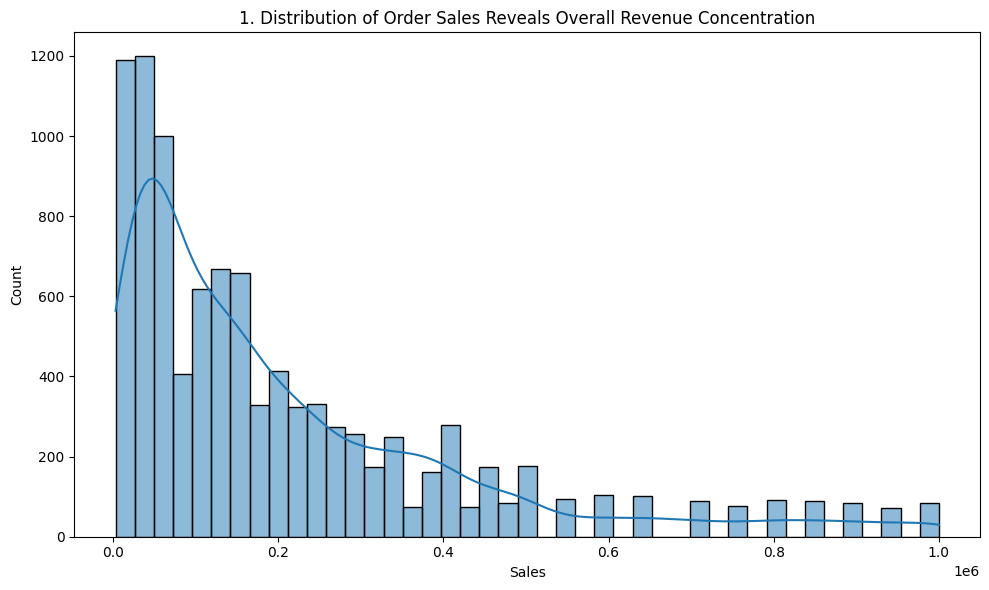

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Sales'], kde=True)
plt.title(f'{plot_no}. Distribution of Order Sales Reveals Overall Revenue Concentration')
show_fig()
plot_no += 1

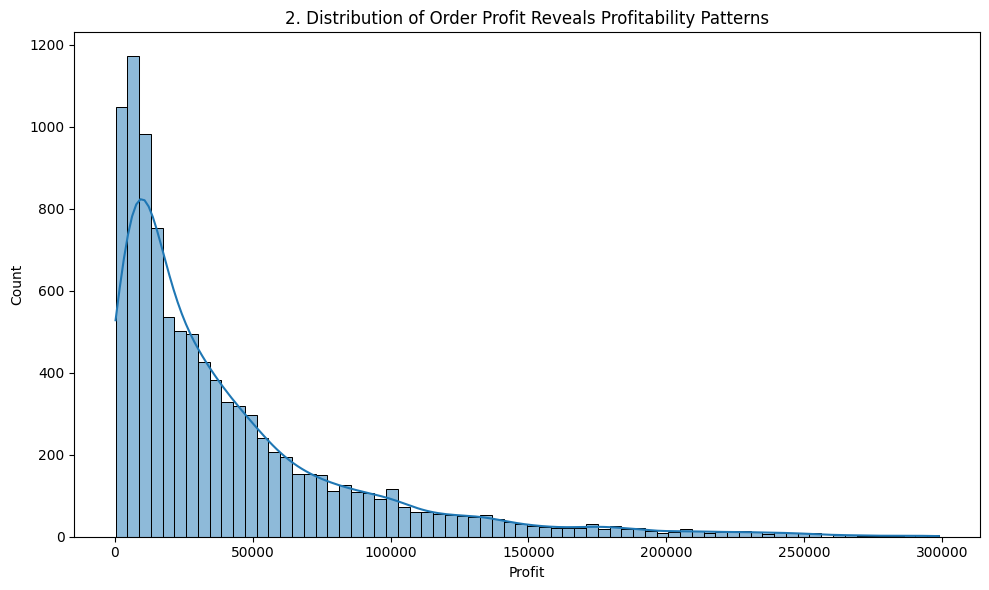

In [14]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['Profit'], kde=True)
plt.title(f'{plot_no}. Distribution of Order Profit Reveals Profitability Patterns')
show_fig()
plot_no += 1

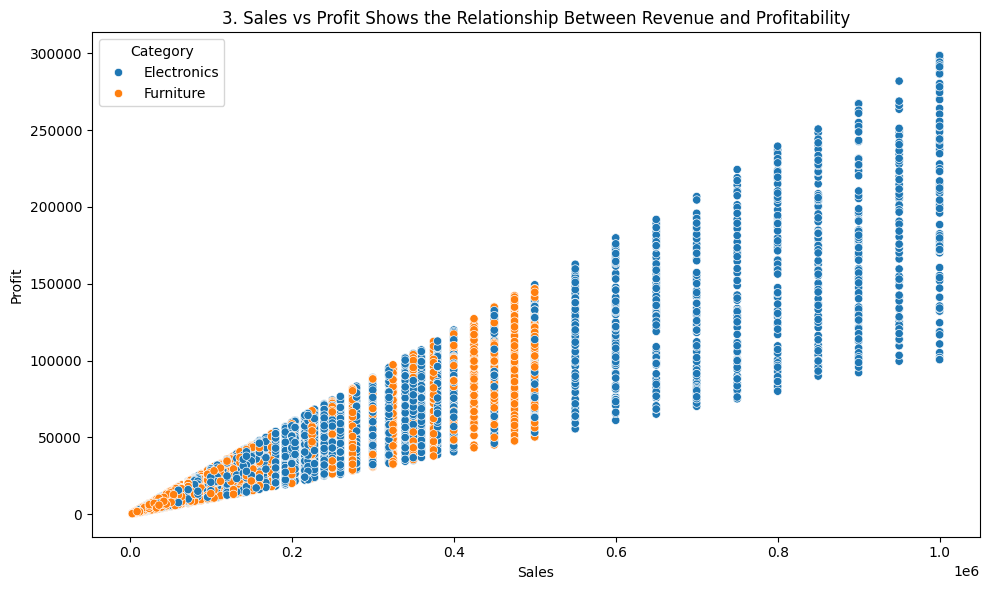

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sales', y='Profit', hue='Category')
plt.title(f'{plot_no}. Sales vs Profit Shows the Relationship Between Revenue and Profitability')
show_fig()
plot_no += 1

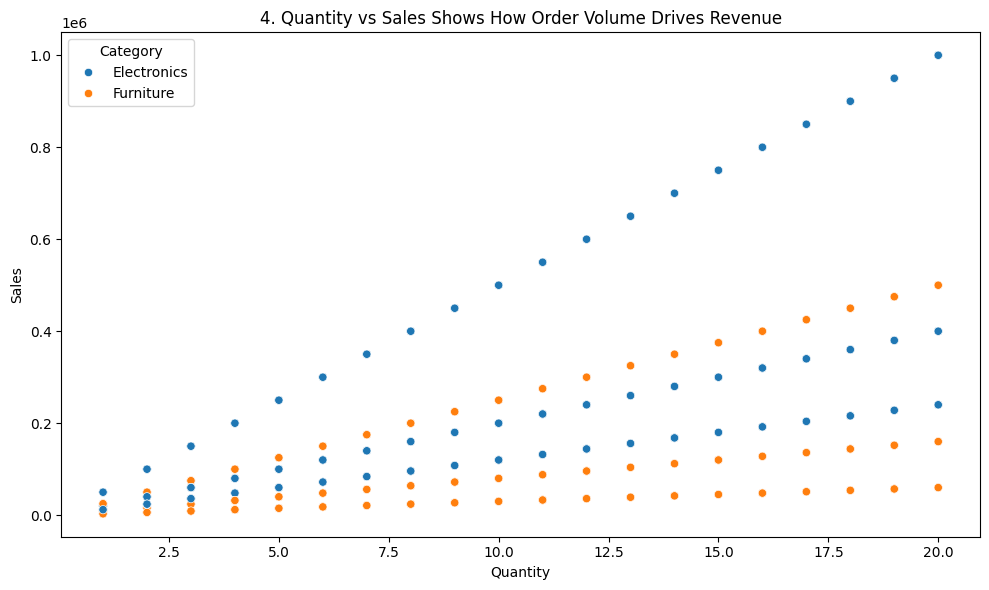

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Quantity', y='Sales', hue='Category')
plt.title(f'{plot_no}. Quantity vs Sales Shows How Order Volume Drives Revenue')
show_fig()
plot_no += 1

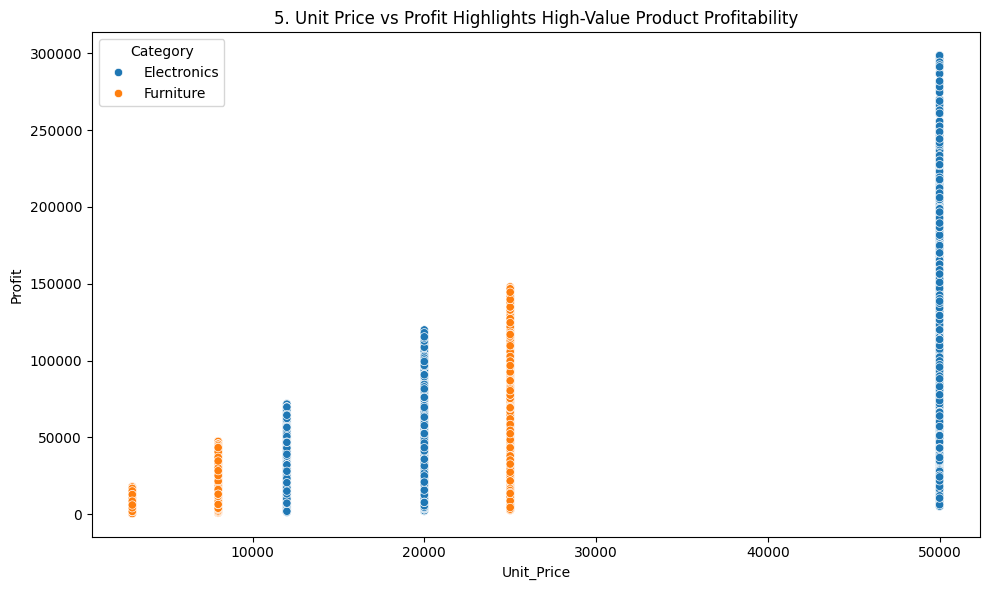

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Unit_Price', y='Profit', hue='Category')
plt.title(f'{plot_no}. Unit Price vs Profit Highlights High-Value Product Profitability')
show_fig()
plot_no += 1

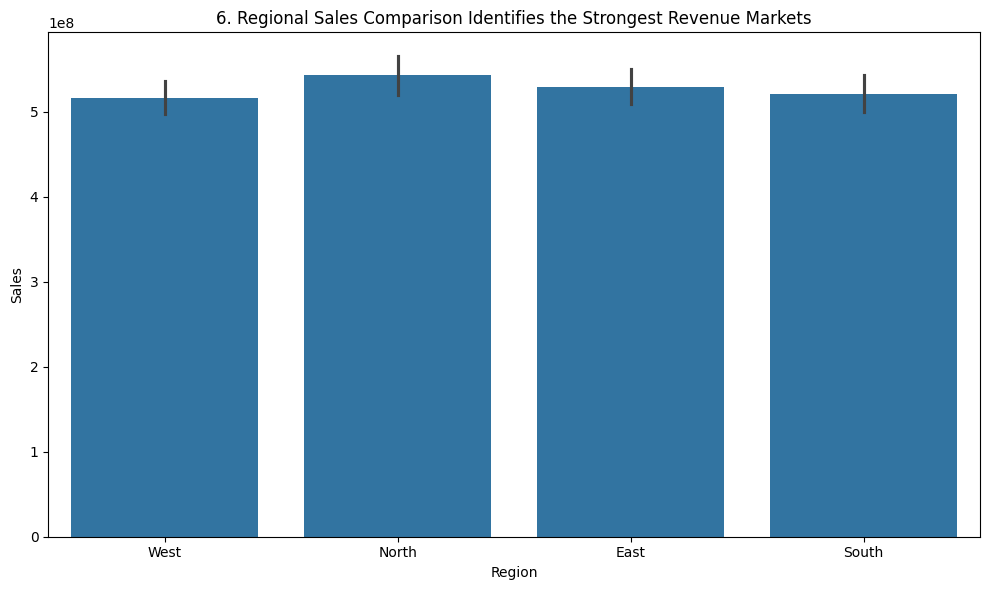

In [18]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Region', y='Sales', estimator='sum')
plt.title(f'{plot_no}. Regional Sales Comparison Identifies the Strongest Revenue Markets')
show_fig()
plot_no += 1

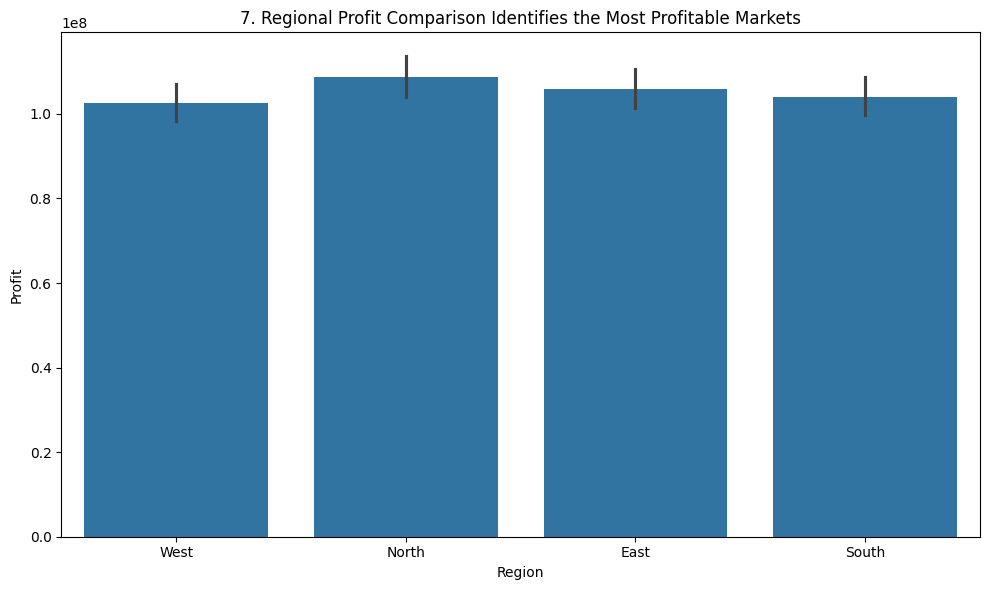

In [19]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Region', y='Profit', estimator='sum')
plt.title(f'{plot_no}. Regional Profit Comparison Identifies the Most Profitable Markets')
show_fig()
plot_no += 1

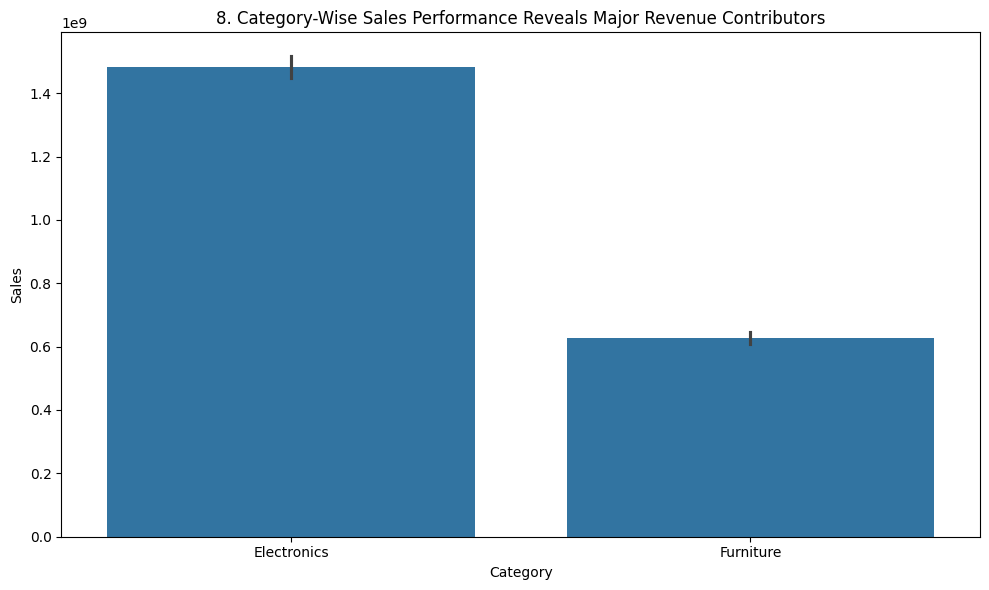

In [20]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Category', y='Sales', estimator='sum')
plt.title(f'{plot_no}. Category-Wise Sales Performance Reveals Major Revenue Contributors')
show_fig()
plot_no += 1

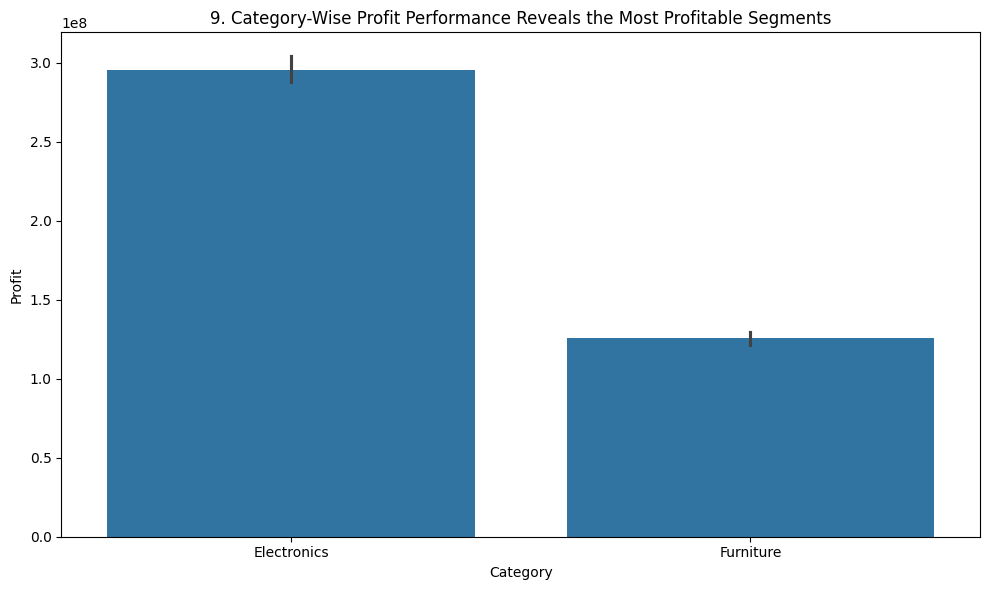

In [21]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Category', y='Profit', estimator='sum')
plt.title(f'{plot_no}. Category-Wise Profit Performance Reveals the Most Profitable Segments')
show_fig()
plot_no += 1

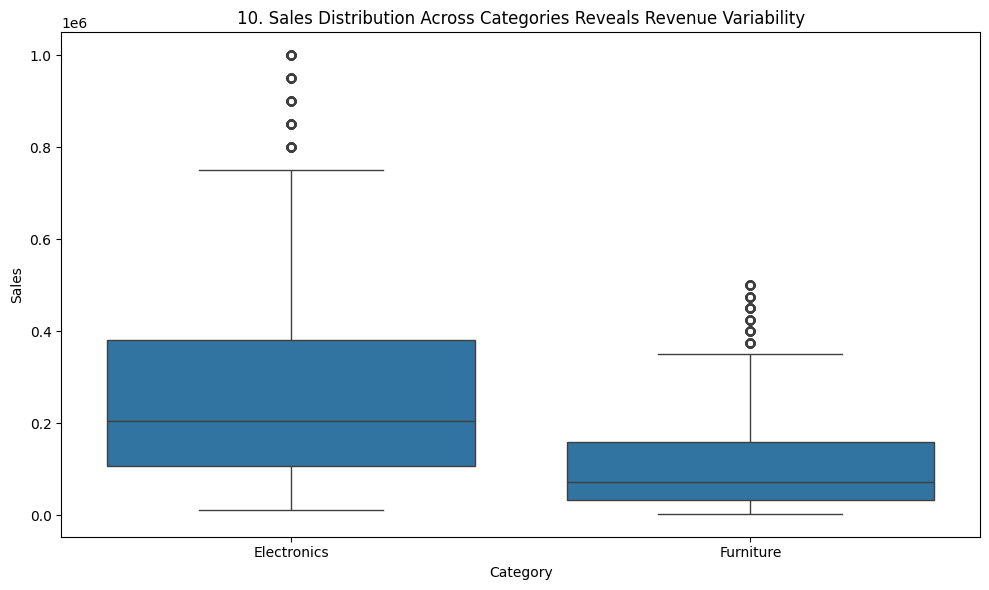

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Category', y='Sales')
plt.title(f'{plot_no}. Sales Distribution Across Categories Reveals Revenue Variability')
show_fig()
plot_no += 1

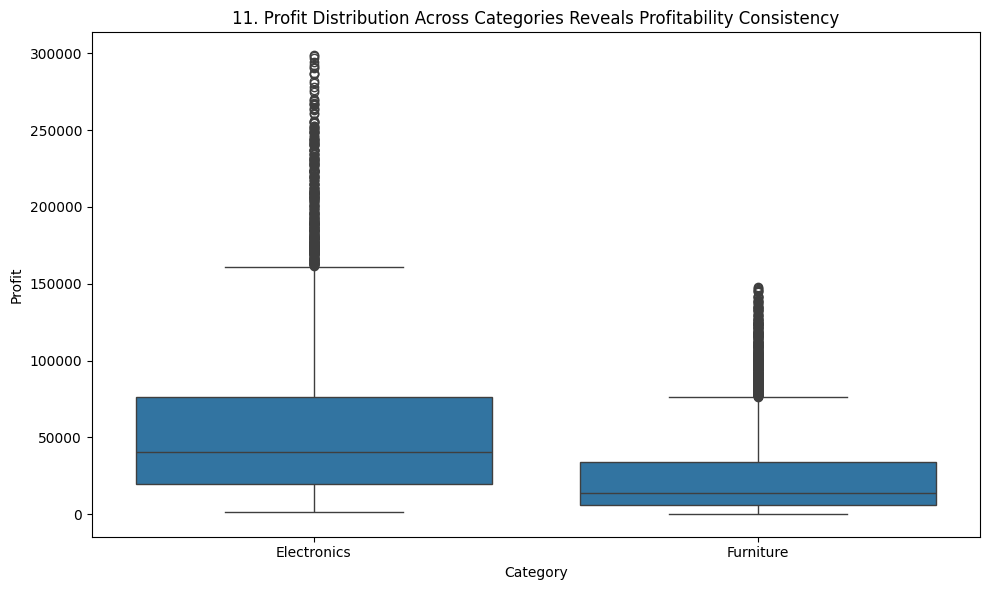

In [23]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Category', y='Profit')
plt.title(f'{plot_no}. Profit Distribution Across Categories Reveals Profitability Consistency')
show_fig()
plot_no += 1

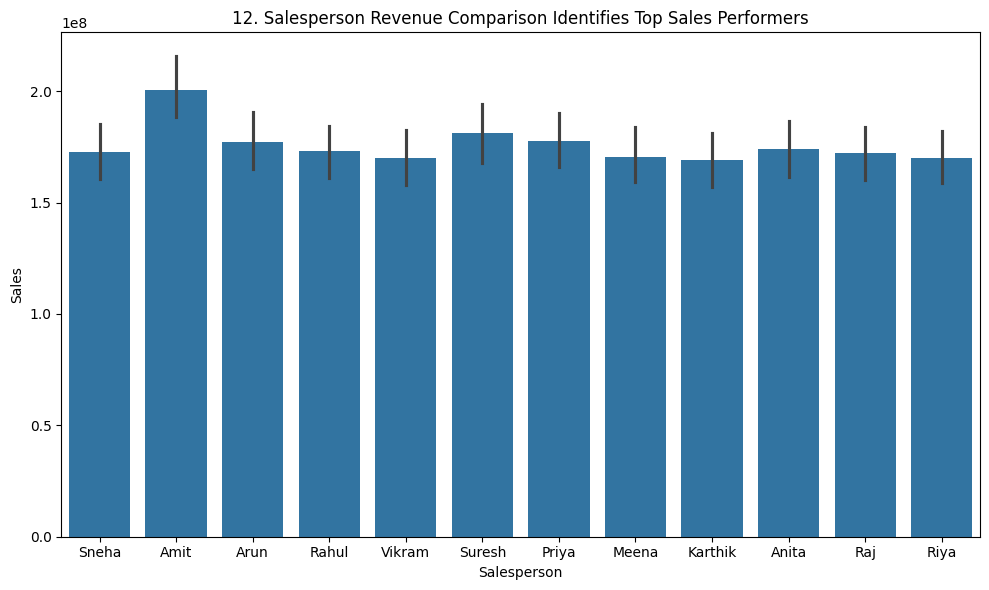

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Salesperson', y='Sales', estimator='sum')
plt.title(f'{plot_no}. Salesperson Revenue Comparison Identifies Top Sales Performers')
show_fig()
plot_no += 1

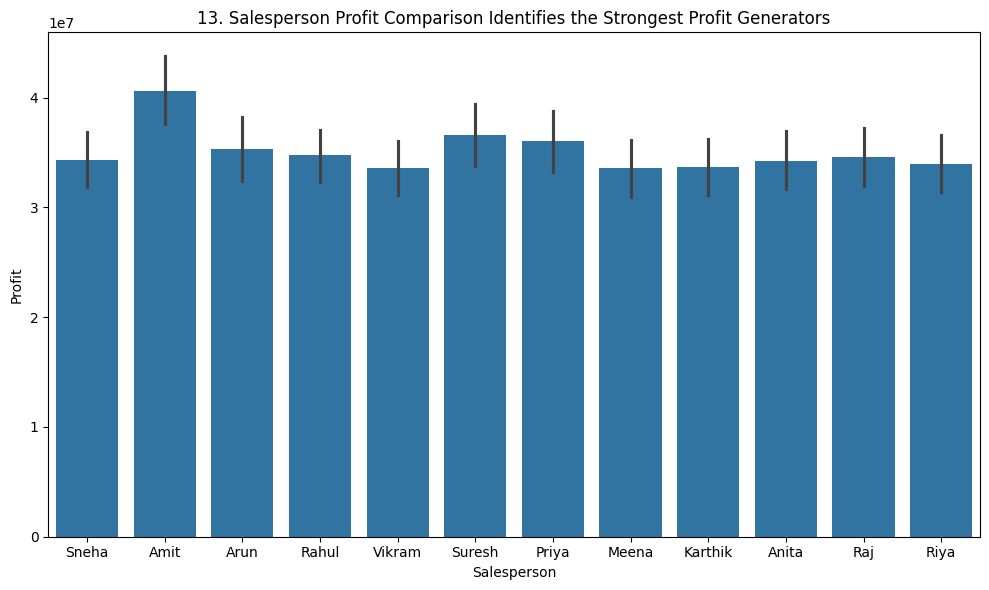

In [25]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Salesperson', y='Profit', estimator='sum')
plt.title(f'{plot_no}. Salesperson Profit Comparison Identifies the Strongest Profit Generators')
show_fig()
plot_no += 1

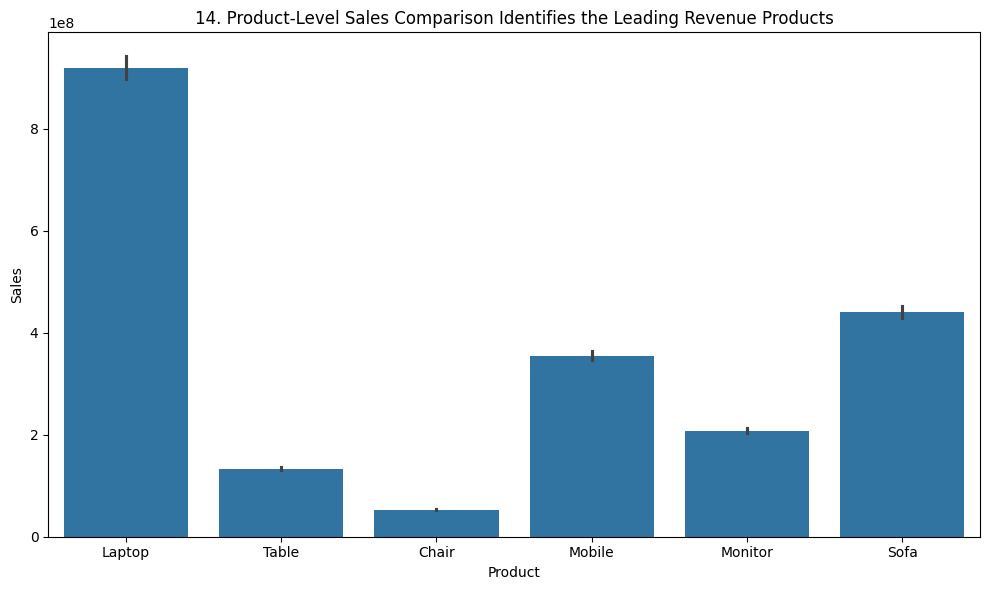

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Product', y='Sales', estimator='sum')
plt.title(f'{plot_no}. Product-Level Sales Comparison Identifies the Leading Revenue Products')
show_fig()
plot_no += 1

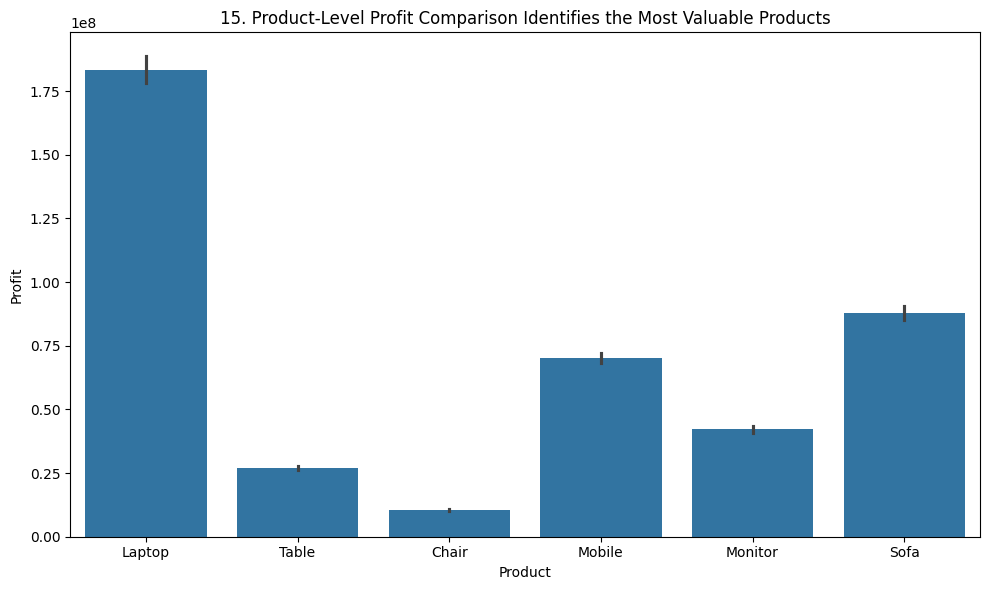

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='Product', y='Profit', estimator='sum')
plt.title(f'{plot_no}. Product-Level Profit Comparison Identifies the Most Valuable Products')
show_fig()
plot_no += 1

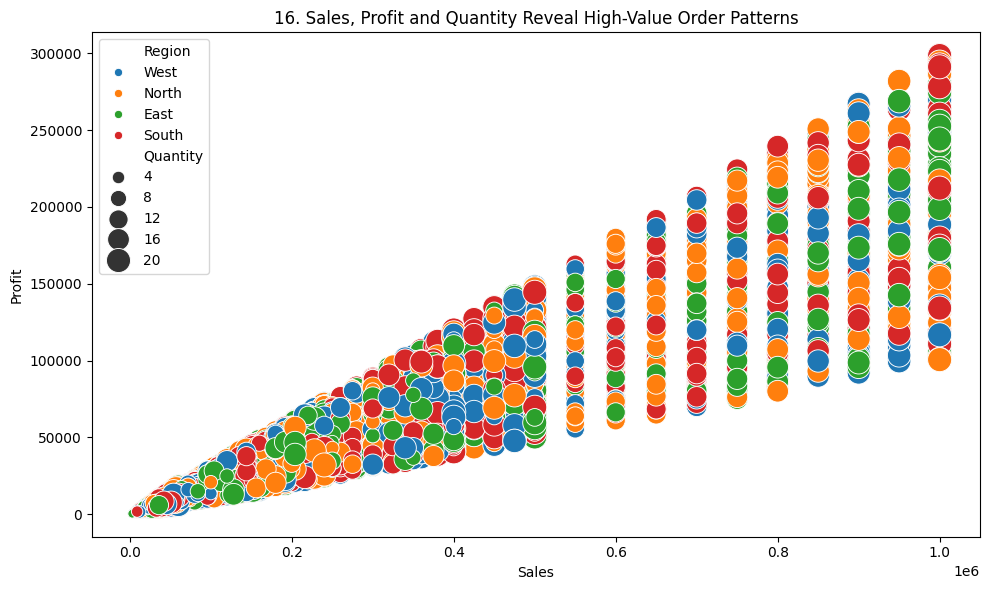

In [28]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Sales', y='Profit', size='Quantity', hue='Region', sizes=(40,300))
plt.title(f'{plot_no}. Sales, Profit and Quantity Reveal High-Value Order Patterns')
show_fig()
plot_no += 1

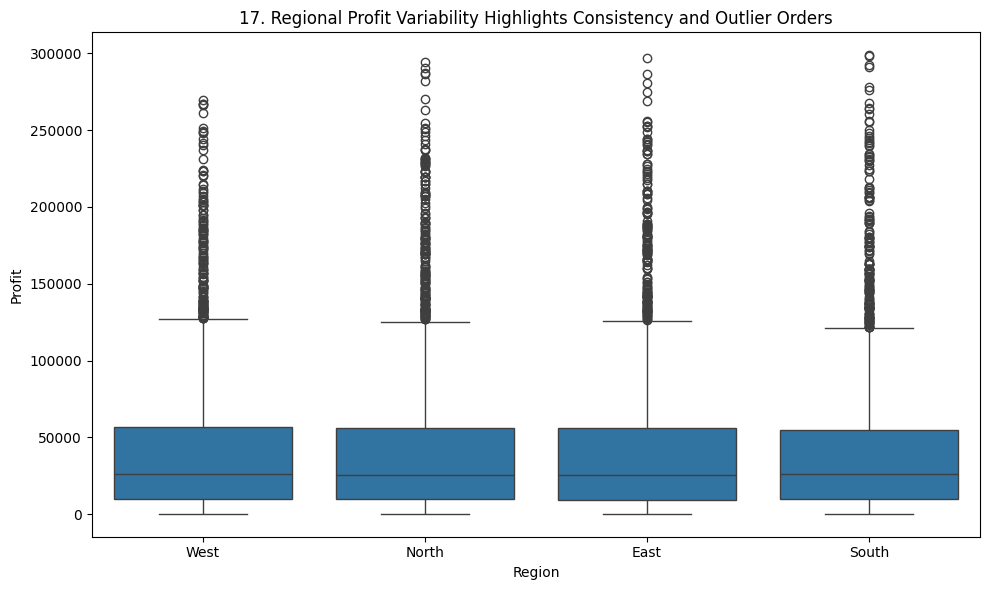

In [29]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Region', y='Profit')
plt.title(f'{plot_no}. Regional Profit Variability Highlights Consistency and Outlier Orders')
show_fig()
plot_no += 1

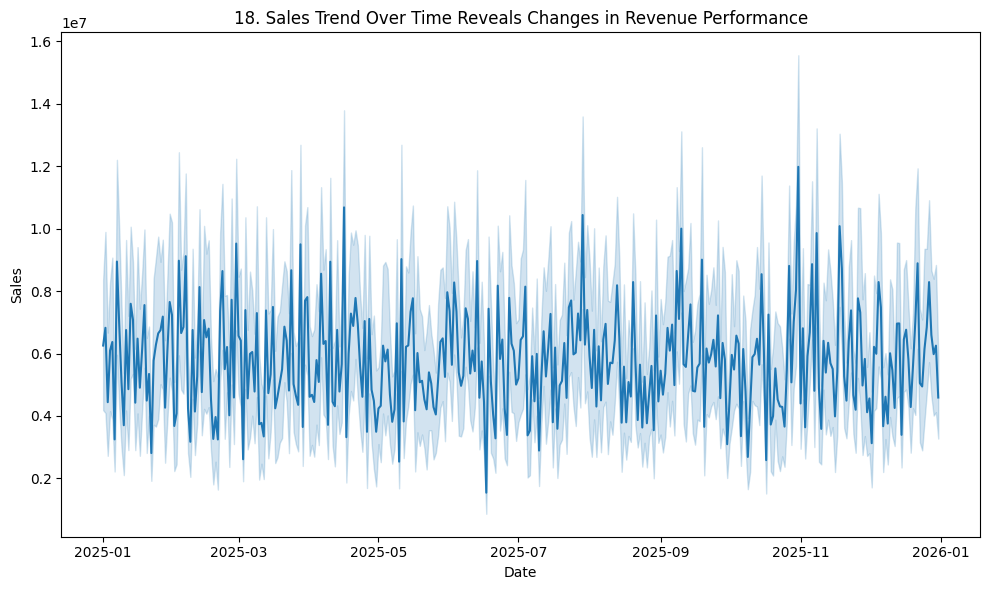

In [30]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.assign(Date=pd.to_datetime(df['Date'])).sort_values('Date'), x='Date', y='Sales', estimator='sum')
plt.title(f'{plot_no}. Sales Trend Over Time Reveals Changes in Revenue Performance')
show_fig()
plot_no += 1

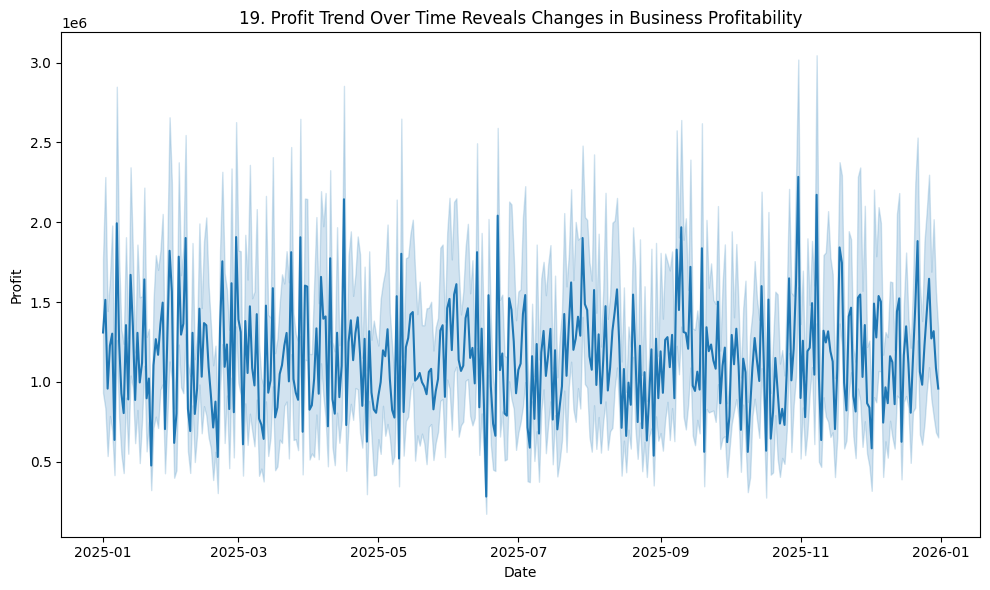

In [31]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(data=df.assign(Date=pd.to_datetime(df['Date'])).sort_values('Date'), x='Date', y='Profit', estimator='sum')
plt.title(f'{plot_no}. Profit Trend Over Time Reveals Changes in Business Profitability')
show_fig()
plot_no += 1

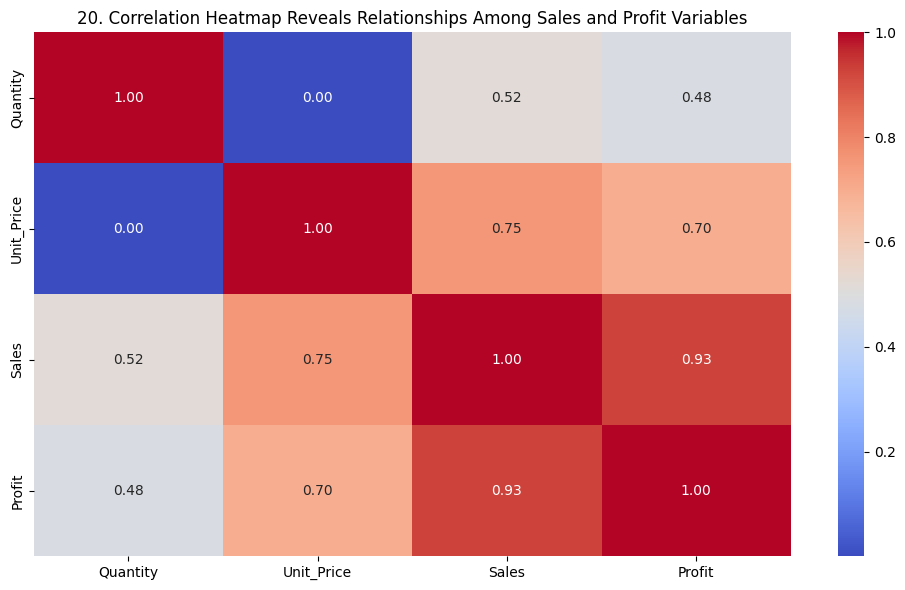

In [32]:
corr = df.select_dtypes(include='number').corr()
fig = plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap Reveals Relationships Among Sales and Profit Variables')
show_fig()
plot_no += 1

# Model Training

## Select the target and create a binary classification target

In [33]:
target = 'Profit'
X = df.drop(columns=[target, 'Order_ID', 'Date'], errors='ignore')
y = (df[target] > df[target].median()).astype(int)

## Separate numerical and categorical features

In [34]:
numeric_cols = X.select_dtypes(include='number').columns
categorical_cols = X.select_dtypes(exclude='number').columns

## Prepare numerical features

In [35]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

## Prepare categorical features

In [36]:
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

## Combine numerical and categorical preprocessing

In [37]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

## Create the classification model

In [38]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42
    ))
])

## Split the dataset into training and testing sets

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Train the model

In [40]:
model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Generate predictions

In [41]:
y_pred = model.predict(X_test)

## Calculate and print model accuracy

In [42]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 90.95%


## Create the confusion matrix

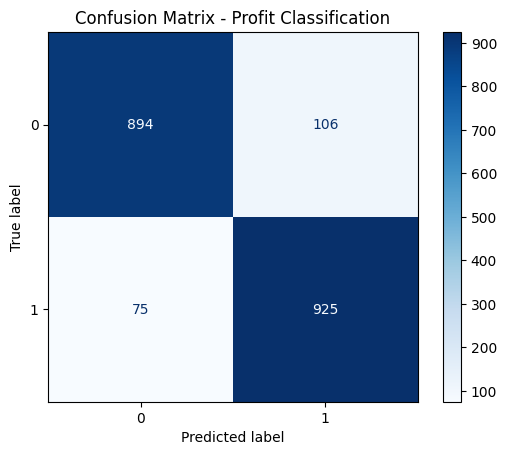

In [43]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Confusion Matrix - Profit Classification')
plt.show()